# DataFlow — Pipeline de Calidad del Aire
## Proyecto Integrador | Fundamentos de Bases de Datos

**Estudiantes:**

*   Anyi Velandía
*   Diego Vega


### Flujo del pipeline
```
Supabase (PostgreSQL)                     MongoDB Atlas
──────────────────────                    ──────────────────────
ciudades                                  resumen_diario
estaciones          ──► ETL (Python) ──►  predicciones
contaminantes                             log_etl
clima_diario
mediciones_raw
```

| # | Sección |
|---|---|
| 0 | Setup — instalación, credenciales, Drive |
| 1 | Estructuras — DDL Supabase + colecciones MongoDB |
| 2 | Carga — CSVs desde Drive a Supabase |
| 3 | Limpieza — nulos y outliers |
| 4 | ETL + MongoDB — transformación y carga documental |
| 5 | Modelo predictivo — Random Forest |
| 6 | Evaluación — métricas, confusión y ROC |


---
## Setup

In [2]:
!pip install psycopg2-binary pymongo pandas numpy scikit-learn matplotlib seaborn certifi -q
print("Dependencias instaladas")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 23.4 MB/s eta 0:00:00
Dependencias instaladas


In [3]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/SQL/data/'
import os
print("  Drive montado")
print("  Archivos:", sorted([f for f in os.listdir(DATA_PATH) if f.endswith(('.csv','.sql'))]))


Mounted at /content/drive
  Drive montado
  Archivos: ['01_supabase_ddl.sql', 'ciudades.csv', 'clima_diario.csv', 'contaminantes.csv', 'estaciones.csv', 'mediciones_raw.csv']


In [4]:
from google.colab import userdata

SUPABASE_POOLER_HOST = userdata.get("SUPABASE_POOLER_HOST")
SUPABASE_PASSWORD    = userdata.get("SUPABASE_PASSWORD")
MONGO_URI            = userdata.get("MONGO_URI")

PG_CONFIG = {
    "host":     SUPABASE_POOLER_HOST,
    "port":     6543,
    "database": "postgres",
    "user":     "postgres.esxzxzxieqlibpskfbpv",
    "password": SUPABASE_PASSWORD,
    "sslmode":  "require",
}

MONGO_DB   = "ActividadFinal"
MONGO_COLL = "resumen_diario"

print("  Credenciales cargadas")
print(f"   Supabase pooler : {SUPABASE_POOLER_HOST}:6543")
print(f"   MongoDB DB      : {MONGO_DB}")


  Credenciales cargadas
   Supabase pooler : aws-1-us-west-2.pooler.supabase.com:6543
   MongoDB DB      : ActividadFinal


In [5]:
import pandas as pd
import numpy as np
import psycopg2
from psycopg2.extras import execute_values
from pymongo import MongoClient, UpdateOne, ASCENDING, DESCENDING
from pymongo.errors import CollectionInvalid
import matplotlib.pyplot as plt
import seaborn as sns
import certifi, json, pickle, time, os, warnings
from datetime import datetime
warnings.filterwarnings("ignore")

# ── Función de conexión MongoDB con certifi (resuelve SSL en Colab)
def get_mongo():
    return MongoClient(
        MONGO_URI,
        serverSelectionTimeoutMS=20000,
        tlsCAFile=certifi.where()
    )

print(" Imports y get_mongo() listos")


 Imports y get_mongo() listos


---
## Sección 1 — Estructuras

### 1.1 Supabase — ejecutar DDL
### 1.2 MongoDB — crear colecciones de destino del ETL


In [5]:
# ── 1.2 MongoDB: colecciones de destino del ETL ──────────────────
client = get_mongo()
db     = client[MONGO_DB]
print(f" Conectado a MongoDB — base de datos: '{MONGO_DB}'")

COLECCIONES_ETL = {
    "resumen_diario": "Un documento por estación/día — producto del ETL",
    "predicciones":   "Salida del modelo predictivo",
    "log_etl":        "Registro de ejecuciones del pipeline",
}

for nombre, descripcion in COLECCIONES_ETL.items():
    try:
        db.create_collection(nombre)
        print(f"  '{nombre}' creada — {descripcion}")
    except CollectionInvalid:
        print(f"  '{nombre}' ya existe — omitida")

# Índices resumen_diario
rd = db["resumen_diario"]
rd.create_index([("estacion_id", ASCENDING), ("fecha", ASCENDING)],
                name="idx_estacion_fecha", unique=True)
rd.create_index([("ciudad_id",   ASCENDING), ("fecha", ASCENDING)],
                name="idx_ciudad_fecha")
rd.create_index([("ica_calculado", ASCENDING)], name="idx_ica")
rd.create_index([("categoria",     ASCENDING)], name="idx_categoria")
print("  Índices de 'resumen_diario' creados")

# Índice predicciones
db["predicciones"].create_index(
    [("estacion_id", ASCENDING), ("fecha_prediccion", ASCENDING)],
    name="idx_pred", unique=True)
print("  Índice de 'predicciones' creado")

# Log
db["log_etl"].insert_one({
    "tipo":      "creacion_estructura",
    "timestamp": datetime.utcnow().isoformat(),
    "estado":    "exitoso",
    "nota":      "Colecciones de destino ETL creadas"
})

print(f"\n MongoDB listo — colecciones: {sorted(db.list_collection_names())}")
client.close()


 Conectado a MongoDB — base de datos: 'ActividadFinal'
  'resumen_diario' ya existe — omitida
  'predicciones' ya existe — omitida
  'log_etl' ya existe — omitida
  Índices de 'resumen_diario' creados
  Índice de 'predicciones' creado

 MongoDB listo — colecciones: ['log_etl', 'predicciones', 'resumen_diario']


---
##  Sección 2 — Carga de CSVs desde Drive a Supabase

Lee los 5 archivos CSV desde Drive y los carga a las tablas relacionales de Supabase.


In [26]:
# Leer CSVs desde Drive
print("Leyendo archivos CSV desde Drive...")
ciudades_df      = pd.read_csv(DATA_PATH + "ciudades.csv")
estaciones_df    = pd.read_csv(DATA_PATH + "estaciones.csv")
contaminantes_df = pd.read_csv(DATA_PATH + "contaminantes.csv")
clima_df         = pd.read_csv(DATA_PATH + "clima_diario.csv")
mediciones_df    = pd.read_csv(DATA_PATH + "mediciones_raw.csv")

# Tipos correctos
clima_df["lluvia"]             = clima_df["lluvia"].astype(bool)
clima_df["es_festivo"]         = clima_df["es_festivo"].astype(bool)
mediciones_df["flag_anomalia"] = mediciones_df["flag_anomalia"].astype(bool)

print(f"  ciudades.csv        {len(ciudades_df):>8,} filas")
print(f"  estaciones.csv      {len(estaciones_df):>8,} filas")
print(f"  contaminantes.csv   {len(contaminantes_df):>8,} filas")
print(f"  clima_diario.csv    {len(clima_df):>8,} filas")
print(f"  mediciones_raw.csv  {len(mediciones_df):>8,} filas")
print(f"\n CSVs cargados en memoria")


Leyendo archivos CSV desde Drive...
  ciudades.csv               3 filas
  estaciones.csv            15 filas
  contaminantes.csv          5 filas
  clima_diario.csv         546 filas
  mediciones_raw.csv   327,600 filas

 CSVs cargados en memoria


In [28]:
# Vista previa
print("── ciudades ──");      display(ciudades_df)
print("── contaminantes ──"); display(contaminantes_df)
print("── estaciones (muestra) ──"); display(estaciones_df.head(3))
print("── clima_diario (muestra) ──"); display(clima_df.head(3))
print("── mediciones_raw (muestra) ──"); display(mediciones_df.head(5))


── ciudades ──


,ciudad_id,nombre,altitud_msnm,poblacion,departamento
0,1,Bogotá,2600,7400000,Cundinamarca
1,2,Medellín,1495,2600000,Antioquia
2,3,Cali,995,2200000,Valle del Cauca


── contaminantes ──


,contaminante_id,nombre,unidad,limite_legal_diario,descripcion
0,1,PM2.5,µg/m³,25.0,Partículas finas < 2.5 µm
1,2,PM10,µg/m³,50.0,Partículas gruesas < 10 µm
2,3,NO2,µg/m³,40.0,Dióxido de nitrógeno
3,4,O3,µg/m³,100.0,Ozono troposférico
4,5,CO,mg/m³,10.0,Monóxido de carbono


── estaciones (muestra) ──


,estacion_id,ciudad_id,nombre,latitud,longitud,fecha_instalacion
0,1,1,Kennedy,4.6258,-74.1478,2019-03-10
1,2,1,Usaquén,4.7069,-74.0317,2018-07-22
2,3,1,Fontibón,4.6680,-74.1469,2020-01-15


── clima_diario (muestra) ──


,clima_id,ciudad_id,fecha,temperatura_c,humedad_pct,viento_kmh,lluvia,mm_lluvia,es_festivo
0,1,1,2024-01-01,15.0,73.9,14.6,False,0.0,True
1,2,1,2024-01-02,17.0,77.2,16.0,True,1.4,False
2,3,1,2024-01-03,12.8,70.8,9.7,False,0.0,False


── mediciones_raw (muestra) ──


,medicion_id,estacion_id,contaminante_id,valor,timestamp,flag_anomalia
0,1,1,1,8.84,2024-01-01 00:45:12,False
1,2,1,2,29.72,2024-01-01 00:40:15,False
2,3,1,3,21.66,2024-01-01 00:54:43,False
3,4,1,4,51.35,2024-01-01 00:36:50,False
4,5,1,5,2.21,2024-01-01 00:42:23,False


In [8]:
# Función de carga por lotes
def cargar_tabla(conn, tabla, df, columnas, batch=5000):
    cur   = conn.cursor()
    filas = [tuple(row) for row in df[columnas].itertuples(index=False)]
    total = len(filas)
    t0    = time.time()
    for i in range(0, total, batch):
        execute_values(cur,
            f"INSERT INTO {tabla} ({', '.join(columnas)}) VALUES %s ON CONFLICT DO NOTHING",
            filas[i:i+batch])
        print(f"  {tabla}: {min(i+batch,total):,}/{total:,}", end="\r")
    conn.commit(); cur.close()
    print(f"  {tabla:<25} {total:>8,} filas  ({time.time()-t0:.1f}s)          ")

print(" Función de carga lista")


 Función de carga lista


In [9]:
# Cargar todas las tablas en Supabase
conn = psycopg2.connect(**PG_CONFIG)
t_total = time.time()
try:
    cargar_tabla(conn, "ciudades",      ciudades_df,
        ["ciudad_id","nombre","altitud_msnm","poblacion","departamento"])
    cargar_tabla(conn, "contaminantes", contaminantes_df,
        ["contaminante_id","nombre","unidad","limite_legal_diario","descripcion"])
    cargar_tabla(conn, "estaciones",    estaciones_df,
        ["estacion_id","ciudad_id","nombre","latitud","longitud","fecha_instalacion"])
    cargar_tabla(conn, "clima_diario",  clima_df,
        ["clima_id","ciudad_id","fecha","temperatura_c","humedad_pct",
         "viento_kmh","lluvia","mm_lluvia","es_festivo"])
    print("  Cargando mediciones_raw (~3 min, archivo grande)...")
    cargar_tabla(conn, "mediciones_raw", mediciones_df,
        ["medicion_id","estacion_id","contaminante_id","valor","timestamp","flag_anomalia"])
except Exception as e:
    conn.rollback(); print(f"❌ Error: {e}")
finally:
    conn.close()
print(f"\n Carga completa en {time.time()-t_total:.1f}s")


  ciudades                         3 filas  (0.4s)          
  contaminantes                    5 filas  (0.4s)          
  estaciones                      15 filas  (0.4s)          
  clima_diario                   546 filas  (1.2s)          
  Cargando mediciones_raw (~3 min, archivo grande)...
  mediciones_raw             327,600 filas  (472.5s)          

 Carga completa en 475.7s


In [6]:
# Verificación final en Supabase
conn = psycopg2.connect(**PG_CONFIG)
cur  = conn.cursor()
print(f"{'Tabla':<25} {'Filas':>10}")
print("-"*37)
for t in ["ciudades","estaciones","contaminantes","clima_diario","mediciones_raw"]:
    cur.execute(f"SELECT COUNT(*) FROM {t}")
    n = cur.fetchone()[0]
    ok = "" if n > 0 else "❌"
    print(f"{ok} {t:<23} {n:>10,}")
cur.execute("SELECT COUNT(*) FROM mediciones_raw WHERE valor IS NULL")
print(f"\n  Nulos    : {cur.fetchone()[0]:,}")
cur.execute("SELECT COUNT(*) FROM mediciones_raw WHERE flag_anomalia = TRUE")
print(f"  Outliers : {cur.fetchone()[0]:,}")
cur.close(); conn.close()


Tabla                          Filas
-------------------------------------
 ciudades                         3
 estaciones                      15
 contaminantes                    5
 clima_diario                   546
 mediciones_raw             327,600

  Nulos    : 0
  Outliers : 2,643


---
## Sección 3 — Limpieza de datos

- Detección y visualización de nulos y outliers
- Imputación con media móvil de 3 horas
- Eliminación de outliers (`flag_anomalia = TRUE`)
- Reporte comparativo antes vs después


In [7]:
# Cargar datos desde Supabase
print("Cargando datos para análisis de calidad...")
conn = psycopg2.connect(**PG_CONFIG)
df_raw = pd.read_sql("""
    SELECT m.medicion_id, m.estacion_id, e.nombre AS estacion,
           c.nombre AS ciudad, co.nombre AS contaminante,
           co.limite_legal_diario, m.valor, m.timestamp,
           m.flag_anomalia, DATE(m.timestamp) AS fecha,
           EXTRACT(HOUR FROM m.timestamp)::INT AS hora
    FROM mediciones_raw  m
    JOIN estaciones      e  ON m.estacion_id     = e.estacion_id
    JOIN ciudades        c  ON e.ciudad_id       = c.ciudad_id
    JOIN contaminantes   co ON m.contaminante_id = co.contaminante_id
""", conn)
clima_raw = pd.read_sql("SELECT * FROM clima_diario", conn)
estaciones_df = pd.read_sql("SELECT * FROM estaciones", conn)
conn.close()

df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"])
df_raw["fecha"]     = pd.to_datetime(df_raw["fecha"])
print(f"{len(df_raw):,} mediciones cargadas")


Cargando datos para análisis de calidad...
327,600 mediciones cargadas


In [9]:
# Reporte ANTES de limpieza
total    = len(df_raw)
nulos    = df_raw["valor"].isna().sum()
outliers = df_raw["flag_anomalia"].sum()

print("REPORTE DE CALIDAD — ANTES DE LIMPIEZA")
print("="*50)
print(f"  Total mediciones : {total:>8,}")
print(f"  Nulos            : {nulos:>8,}  ({nulos/total*100:.2f}%)")
print(f"  Outliers         : {outliers:>8,}  ({outliers/total*100:.2f}%)")
print(f"  Datos válidos    : {total-nulos-outliers:>8,}  ({(total-nulos-outliers)/total*100:.2f}%)")
print("\n  Nulos por contaminante:")
for cont, n in df_raw.groupby("contaminante")["valor"].apply(lambda s: s.isna().sum()).items():
    print(f"    {cont:<8} {n:>6,}")


REPORTE DE CALIDAD — ANTES DE LIMPIEZA
  Total mediciones :  327,600
  Nulos            :    8,302  (2.53%)
  Outliers         :    2,643  (0.81%)
  Datos válidos    :  316,655  (96.66%)

  Nulos por contaminante:
    CO        1,720
    NO2       1,617
    O3        1,682
    PM10      1,700
    PM2.5     1,583


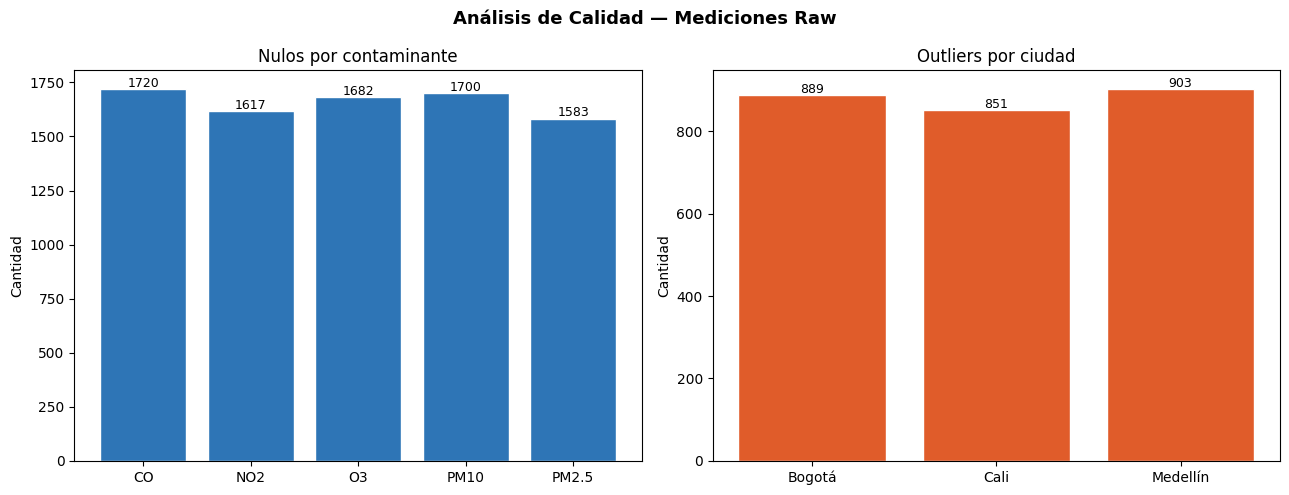

Gráfico guardado en Drive


In [11]:
# Visualización nulos y outliers
fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.suptitle("Análisis de Calidad — Mediciones Raw", fontsize=13, fontweight="bold")

nulos_cont = df_raw.groupby("contaminante")["valor"].apply(lambda s: s.isna().sum())
axes[0].bar(nulos_cont.index, nulos_cont.values, color="#2E75B6", edgecolor="white")
axes[0].set_title("Nulos por contaminante"); axes[0].set_ylabel("Cantidad")
for i,(k,v) in enumerate(nulos_cont.items()):
    axes[0].text(i, v+10, str(v), ha="center", fontsize=9)

out_ciudad = df_raw[df_raw["flag_anomalia"]].groupby("ciudad").size()
axes[1].bar(out_ciudad.index, out_ciudad.values, color="#E05C2A", edgecolor="white")
axes[1].set_title("Outliers por ciudad"); axes[1].set_ylabel("Cantidad")
for i,(k,v) in enumerate(out_ciudad.items()):
    axes[1].text(i, v+5, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(DATA_PATH+"calidad_antes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en Drive")


# Visualizacion grafica anterior, presenta los nulos de los outliers

In [12]:
# Aplicar limpieza
df_limpio = df_raw[~df_raw["flag_anomalia"]].copy()
print(f"  Paso 1 — Outliers eliminados    : {df_raw['flag_anomalia'].sum():,}")

df_limpio = df_limpio.sort_values(["estacion","contaminante","timestamp"])
n_nulos   = df_limpio["valor"].isna().sum()

df_limpio["valor"] = df_limpio.groupby(["estacion","contaminante"])["valor"].transform(
    lambda s: s.fillna(s.rolling(3, min_periods=1, center=True).mean()))
df_limpio["valor"] = df_limpio.groupby(["estacion","contaminante"])["valor"].transform(
    lambda s: s.fillna(s.median()))
df_limpio = df_limpio.dropna(subset=["valor"])

print(f"  Paso 2 — Nulos imputados (m.m. 3h): {n_nulos:,}")
print(f"  Paso 3 — Filas limpias            : {len(df_limpio):,} de {len(df_raw):,} ({len(df_limpio)/len(df_raw)*100:.1f}%)")
print(f"\n DESPUÉS DE LIMPIEZA")
print(f"  Nulos restantes   : {df_limpio['valor'].isna().sum():,}")
print(f"  Outliers restantes: 0")
print(f"  df_limpio listo para el ETL")


  Paso 1 — Outliers eliminados    : 2,643
  Paso 2 — Nulos imputados (m.m. 3h): 8,302
  Paso 3 — Filas limpias            : 324,957 de 327,600 (99.2%)

 DESPUÉS DE LIMPIEZA
  Nulos restantes   : 0
  Outliers restantes: 0
  df_limpio listo para el ETL


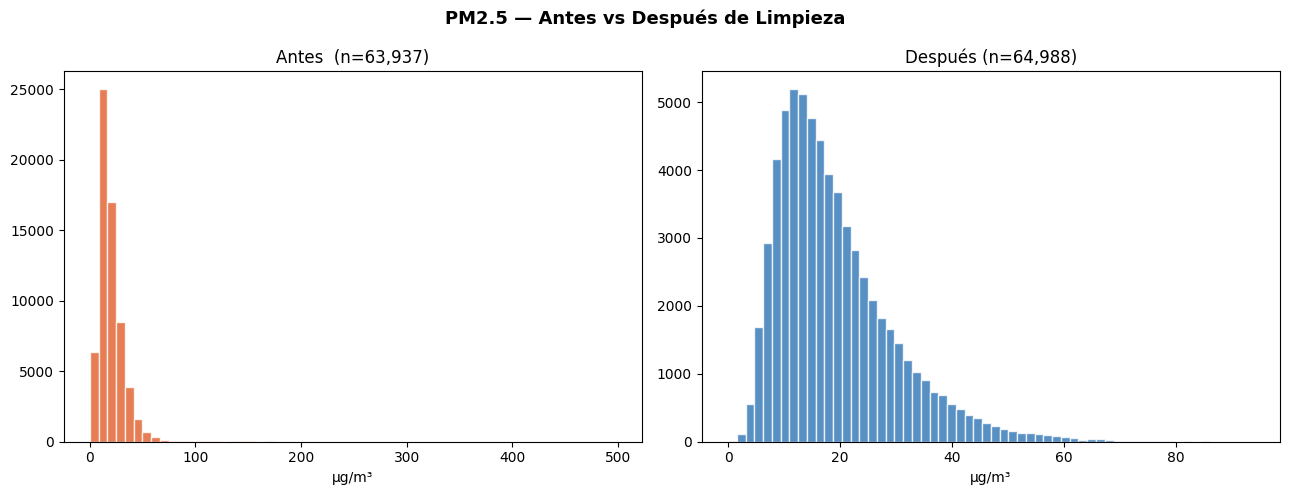

In [13]:
# Distribución PM2.5 antes vs después
fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.suptitle("PM2.5 — Antes vs Después de Limpieza", fontsize=13, fontweight="bold")

pm25_antes   = df_raw[df_raw["contaminante"]=="PM2.5"]["valor"].dropna()
pm25_despues = df_limpio[df_limpio["contaminante"]=="PM2.5"]["valor"]

axes[0].hist(pm25_antes,   bins=60, color="#E05C2A", alpha=0.8, edgecolor="white")
axes[0].set_title(f"Antes  (n={len(pm25_antes):,})"); axes[0].set_xlabel("µg/m³")
axes[1].hist(pm25_despues, bins=60, color="#2E75B6", alpha=0.8, edgecolor="white")
axes[1].set_title(f"Después (n={len(pm25_despues):,})"); axes[1].set_xlabel("µg/m³")

plt.tight_layout()
plt.savefig(DATA_PATH+"calidad_despues.png", dpi=150, bbox_inches="tight")
plt.show()


*   **Antes de la limpieza (izquierda):** Se observa una distribución con una cola más larga y ancha hacia valores altos, indicando la presencia de valores extremos (outliers) que se extienden más allá de los 150 µg/m³. La cantidad de datos es mayor (n=63,937).

*   **Después de la limpieza (derecha):** La distribución es más compacta y centrada, con el rango de valores máximos significativamente reducido (aproximadamente hasta 100 µg/m³). Esto sugiere que la eliminación de outliers y la imputación de nulos han resultado en un conjunto de datos más limpio y representativo, aunque con un ligero aumento en la cantidad de datos (n=64,988), posiblemente debido a la imputación de nulos que antes de realizar el drop en la visualización original de pm25_antes (dropna).


---
##  Sección 4 — ETL + MongoDB Atlas

Transforma los datos limpios de Supabase en documentos enriquecidos:
- 24 lecturas horarias → 1 documento por estación/día
- Cálculo ICA diario (fórmula IDEAM con PM2.5)
- Variables climáticas del día
- Features de lag para el modelo


In [14]:
# Funciones ICA
def calcular_ica(c):
    bp = [(0,12.0,0,50),(12.1,35.4,51,100),(35.5,55.4,101,150),
          (55.5,150.4,151,200),(150.5,250.4,201,300),(250.5,500,301,500)]
    for c_lo,c_hi,i_lo,i_hi in bp:
        if c_lo <= c <= c_hi:
            return round((i_hi-i_lo)/(c_hi-c_lo)*(c-c_lo)+i_lo, 1)
    return 500.0

def categoria_ica(v):
    if v<=50:  return "Bueno"
    if v<=100: return "Moderado"
    if v<=150: return "Dañino para grupos sensibles"
    if v<=200: return "Dañino"
    if v<=300: return "Muy dañino"
    return "Peligroso"

print(" Funciones ICA listas")


 Funciones ICA listas


In [15]:
# Agregación diaria por estación/contaminante
print("Agregando 24 lecturas/día → 1 fila por estación/día/contaminante...")

agg = df_limpio.groupby(
    ["estacion_id","estacion","ciudad","fecha","contaminante"]
).agg(
    promedio   = ("valor","mean"),
    maximo     = ("valor","max"),
    minimo     = ("valor","min"),
    n_lecturas = ("valor","count")
).reset_index()
agg[["promedio","maximo","minimo"]] = agg[["promedio","maximo","minimo"]].round(2)

# Añadir ciudad_id
agg = agg.merge(estaciones_df[["estacion_id","ciudad_id"]], on="estacion_id", how="left")

# Pivotar contaminantes
pivot = agg.pivot_table(
    index=["estacion_id","estacion","ciudad_id","ciudad","fecha"],
    columns="contaminante",
    values=["promedio","maximo","minimo","n_lecturas"],
    aggfunc="first"
)
pivot.columns = ["_".join(col).strip() for col in pivot.columns]
pivot = pivot.reset_index()

# ICA y categoría
if "promedio_PM2.5" in pivot.columns:
    pivot["ica_calculado"] = pivot["promedio_PM2.5"].apply(
        lambda v: calcular_ica(v) if pd.notna(v) else None)
    pivot["categoria"] = pivot["ica_calculado"].apply(
        lambda v: categoria_ica(v) if pd.notna(v) else "Sin dato")

# Unir clima
clima_raw["fecha"] = pd.to_datetime(clima_raw["fecha"])
pivot["fecha"]     = pd.to_datetime(pivot["fecha"])
pivot = pivot.merge(
    clima_raw[["ciudad_id","fecha","temperatura_c","humedad_pct",
               "viento_kmh","lluvia","mm_lluvia","es_festivo"]],
    on=["ciudad_id","fecha"], how="left")

# Features de lag
pivot = pivot.sort_values(["estacion_id","fecha"])
pivot["ica_lag1"]    = pivot.groupby("estacion_id")["ica_calculado"].shift(1)
pivot["ica_lag7"]    = pivot.groupby("estacion_id")["ica_calculado"].shift(7)
pivot["ica_media7d"] = pivot.groupby("estacion_id")["ica_calculado"].transform(
    lambda s: s.shift(1).rolling(7, min_periods=3).mean()).round(1)

print(f" {len(pivot):,} documentos diarios preparados")
display(pivot[["estacion","ciudad","fecha","ica_calculado","categoria"]].head(5))


Agregando 24 lecturas/día → 1 fila por estación/día/contaminante...
 2,730 documentos diarios preparados


,estacion,ciudad,fecha,ica_calculado,categoria
0,Kennedy,Bogotá,2024-01-01,79.0,Moderado
1,Kennedy,Bogotá,2024-01-02,68.3,Moderado
2,Kennedy,Bogotá,2024-01-03,99.3,Moderado
3,Kennedy,Bogotá,2024-01-04,95.2,Moderado
4,Kennedy,Bogotá,2024-01-05,101.6,Dañino para grupos sensibles


In [16]:
# Construir y cargar documentos a MongoDB
def safe(val):
    try:
        if pd.isna(val): return None
    except: pass
    if isinstance(val,(np.integer,)):  return int(val)
    if isinstance(val,(np.floating,)): return float(val)
    if isinstance(val,(np.bool_,)):    return bool(val)
    if isinstance(val, pd.Timestamp):  return str(val.date())
    return val

def construir_doc(row):
    fecha_str = str(row["fecha"])[:10]
    conts = {}
    for cont in ["PM2.5","PM10","NO2","O3","CO"]:
        p = safe(row.get(f"promedio_{cont}"))
        if p is not None:
            conts[cont.replace(".","_")] = {
                "promedio": p,
                "maximo":   safe(row.get(f"maximo_{cont}")),
                "minimo":   safe(row.get(f"minimo_{cont}")),
            }
    return {
        "_id":           f"{int(row['estacion_id'])}_{fecha_str}",
        "estacion_id":   int(row["estacion_id"]),
        "estacion":      row["estacion"],
        "ciudad_id":     int(row["ciudad_id"]),
        "ciudad":        row["ciudad"],
        "fecha":         fecha_str,
        "ica_calculado": safe(row.get("ica_calculado")),
        "categoria":     row.get("categoria","Sin dato"),
        "contaminantes": conts,
        "clima": {
            "temperatura_c": safe(row.get("temperatura_c")),
            "humedad_pct":   safe(row.get("humedad_pct")),
            "viento_kmh":    safe(row.get("viento_kmh")),
            "lluvia":        bool(row["lluvia"]) if pd.notna(row.get("lluvia")) else None,
            "mm_lluvia":     safe(row.get("mm_lluvia")),
            "es_festivo":    bool(row["es_festivo"]) if pd.notna(row.get("es_festivo")) else None,
        },
        "features_ml": {
            "ica_lag1":    safe(row.get("ica_lag1")),
            "ica_lag7":    safe(row.get("ica_lag7")),
            "ica_media7d": safe(row.get("ica_media7d")),
        },
    }

print("Cargando documentos a MongoDB...")
client = get_mongo()
coll   = client[MONGO_DB][MONGO_COLL]
docs   = [construir_doc(row) for _, row in pivot.iterrows()]

for i in range(0, len(docs), 500):
    ops = [UpdateOne({"_id":d["_id"]},{"$set":d},upsert=True) for d in docs[i:i+500]]
    coll.bulk_write(ops, ordered=False)
    print(f"  {min(i+500,len(docs)):,}/{len(docs):,}", end="\r")

# Registrar en log_etl
client[MONGO_DB]["log_etl"].insert_one({
    "tipo":                "etl_carga",
    "timestamp":           datetime.utcnow().isoformat(),
    "documentos_cargados": coll.count_documents({}),
    "estado":              "exitoso"
})

print(f"\n MongoDB '{MONGO_COLL}': {coll.count_documents({}):,} documentos cargados")
client.close()


Cargando documentos a MongoDB...

 MongoDB 'resumen_diario': 2,730 documentos cargados


In [17]:
# Consultas de verificación MongoDB
client = get_mongo()
coll   = client[MONGO_DB][MONGO_COLL]

print(" ICA promedio por ciudad:")
for r in coll.aggregate([
    {"$group": {"_id":"$ciudad","ica_avg":{"$avg":"$ica_calculado"},"docs":{"$count":{}}}},
    {"$sort":  {"ica_avg":-1}}
]):
    print(f"  {r['_id']:<12}  ICA={r['ica_avg']:.1f}  docs={r['docs']:,}")

print("\n Distribución de categorías ICA:")
for r in coll.aggregate([
    {"$group": {"_id":"$categoria","total":{"$count":{}}}},
    {"$sort":  {"total":-1}}
]):
    print(f"  {r['_id']:<35} {r['total']:>5,}")

print("\n📄 Ejemplo de documento:")
doc = coll.find_one({}, {"_id":0,"estacion":1,"ciudad":1,"fecha":1,
    "ica_calculado":1,"categoria":1,"contaminantes":1,"features_ml":1})
print(json.dumps(doc, indent=2, default=str))
client.close()


 ICA promedio por ciudad:
  Bogotá        ICA=75.4  docs=910
  Medellín      ICA=65.1  docs=910
  Cali          ICA=62.5  docs=910

 Distribución de categorías ICA:
  Moderado                            2,333
  Bueno                                 331
  Dañino para grupos sensibles           52
  Peligroso                              14

📄 Ejemplo de documento:
{
  "categoria": "Moderado",
  "ciudad": "Bogot\u00e1",
  "contaminantes": {
    "PM2_5": {
      "promedio": 25.42,
      "maximo": 48.08,
      "minimo": 8.84
    },
    "PM10": {
      "promedio": 43.34,
      "maximo": 91.4,
      "minimo": 10.18
    },
    "NO2": {
      "promedio": 35.57,
      "maximo": 72.32,
      "minimo": 17.62
    },
    "O3": {
      "promedio": 60.76,
      "maximo": 113.41,
      "minimo": 18.57
    },
    "CO": {
      "promedio": 3.3,
      "maximo": 5.72,
      "minimo": 1.35
    }
  },
  "estacion": "Kennedy",
  "features_ml": {
    "ica_lag1": null,
    "ica_lag7": null,
    "ica_media7d": 

---
## Sección 5 — Modelo Predictivo (Random Forest)

- **Fuente**: MongoDB Atlas — `resumen_diario`
- **Target regresión**: ICA numérico del día siguiente
- **Target clasificación**: categoría ICA del día siguiente
- **Validación**: split temporal 80/20


In [18]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report, roc_curve, auc)
from sklearn.preprocessing import LabelEncoder, label_binarize

# Extraer features desde MongoDB
print("Extrayendo features desde MongoDB...")
client = get_mongo()
coll   = client[MONGO_DB][MONGO_COLL]

registros = []
for doc in coll.find({}, {"_id":0,"estacion_id":1,"ciudad_id":1,"ciudad":1,
    "fecha":1,"ica_calculado":1,"clima":1,"features_ml":1,"contaminantes":1}):
    cl=doc.get("clima",{}); ft=doc.get("features_ml",{}); co=doc.get("contaminantes",{})
    registros.append({
        "estacion_id":  doc["estacion_id"], "ciudad": doc["ciudad"], "fecha": doc["fecha"],
        "ica_actual":   doc.get("ica_calculado"),
        "temperatura":  cl.get("temperatura_c"), "humedad":    cl.get("humedad_pct"),
        "viento":       cl.get("viento_kmh"),    "lluvia":     1 if cl.get("lluvia") else 0,
        "mm_lluvia":    cl.get("mm_lluvia",0),   "es_festivo": 1 if cl.get("es_festivo") else 0,
        "ica_lag1":     ft.get("ica_lag1"),      "ica_lag7":   ft.get("ica_lag7"),
        "ica_media7d":  ft.get("ica_media7d"),
        "pm25": co.get("PM2_5",{}).get("promedio"),
        "pm10": co.get("PM10",{}).get("promedio"),
        "no2":  co.get("NO2",{}).get("promedio"),
    })
client.close()

df_ml = pd.DataFrame(registros)
df_ml["fecha"]         = pd.to_datetime(df_ml["fecha"])
df_ml                  = df_ml.sort_values(["estacion_id","fecha"])
df_ml["dia_semana"]    = df_ml["fecha"].dt.dayofweek
df_ml["mes"]           = df_ml["fecha"].dt.month
df_ml["es_fin_semana"] = (df_ml["dia_semana"]>=5).astype(int)
df_ml["ica_manana"]    = df_ml.groupby("estacion_id")["ica_actual"].shift(-1)

le = LabelEncoder()
df_ml["ciudad_cod"] = le.fit_transform(df_ml["ciudad"])
df_ml = df_ml.dropna(subset=["ica_manana","ica_lag1"])

FEATURES   = ["ica_lag1","ica_lag7","ica_media7d","temperatura","humedad","viento",
              "lluvia","mm_lluvia","es_festivo","pm25","pm10","no2",
              "dia_semana","mes","es_fin_semana","ciudad_cod"]
CAT_LABELS = ["Bueno","Moderado","Dañino GS","Dañino","Muy dañino"]

def cat_num(v):
    if v<=50: return 0
    if v<=100: return 1
    if v<=150: return 2
    if v<=200: return 3
    return 4

X     = df_ml[FEATURES].fillna(df_ml[FEATURES].median())
y_reg = df_ml["ica_manana"]
y_cat = y_reg.apply(cat_num)
print(f" Dataset ML: {len(df_ml):,} filas | {len(FEATURES)} features")


Extrayendo features desde MongoDB...
 Dataset ML: 2,700 filas | 16 features


In [19]:
# Split temporal 80/20 y entrenamiento
df_sorted  = df_ml.sort_values("fecha")
cutoff     = int(len(df_sorted)*0.80)
idx_train  = df_sorted.index[:cutoff]
idx_test   = df_sorted.index[cutoff:]

X_train,  X_test  = X.loc[idx_train], X.loc[idx_test]
y_tr_reg, y_te_reg = y_reg.loc[idx_train], y_reg.loc[idx_test]
y_tr_cat, y_te_cat = y_cat.loc[idx_train], y_cat.loc[idx_test]

print(f"Train: {len(X_train):,} | Test: {len(X_test):,} | Corte: {df_sorted['fecha'].iloc[cutoff].date()}")

reg = RandomForestRegressor(n_estimators=150, max_depth=12,
                             min_samples_leaf=5, random_state=42, n_jobs=-1)
reg.fit(X_train, y_tr_reg)
y_pred_reg = reg.predict(X_test)

clf = RandomForestClassifier(n_estimators=150, max_depth=12,
                              min_samples_leaf=5, random_state=42, n_jobs=-1)
clf.fit(X_train, y_tr_cat)
y_pred_cat   = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)
print(" Modelos entrenados (regresión + clasificación)")


Train: 2,160 | Test: 540 | Corte: 2024-05-25
 Modelos entrenados (regresión + clasificación)


In [20]:
# Guardar modelos en Drive
MODEL_PATH = DATA_PATH + "modelo_output/"
os.makedirs(MODEL_PATH, exist_ok=True)

with open(MODEL_PATH+"modelo_regresion.pkl","wb") as f:
    pickle.dump({"model":reg,"features":FEATURES,"label_encoder":le}, f)
with open(MODEL_PATH+"modelo_clasificacion.pkl","wb") as f:
    pickle.dump({"model":clf,"features":FEATURES,"cat_labels":CAT_LABELS}, f)

mae  = mean_absolute_error(y_te_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_te_reg, y_pred_reg))
r2   = r2_score(y_te_reg, y_pred_reg)

with open(MODEL_PATH+"reporte_metricas.json","w") as f:
    json.dump({"MAE":round(mae,2),"RMSE":round(rmse,2),"R2":round(r2,4),
               "features":FEATURES,"cat_labels":CAT_LABELS}, f, indent=2)

# Guardar predicciones en MongoDB
client = get_mongo()
pred_coll = client[MONGO_DB]["predicciones"]
fechas_test = df_sorted.iloc[cutoff:]["fecha"].values
for i,(est_id,pred_val,cat_val) in enumerate(
        zip(df_sorted.iloc[cutoff:]["estacion_id"].values, y_pred_reg, y_pred_cat)):
    pred_coll.update_one(
        {"estacion_id":int(est_id),"fecha_prediccion":str(fechas_test[i])[:10]},
        {"$set":{"ica_predicho":round(float(pred_val),1),
                 "categoria_predicha":CAT_LABELS[int(cat_val)],
                 "fecha_generacion":datetime.utcnow().isoformat()}},
        upsert=True)
client.close()

print(f" Modelos guardados en {MODEL_PATH}")
print(f" {pred_coll.count_documents({}) if False else len(y_pred_reg):,} predicciones guardadas en MongoDB")


 Modelos guardados en /content/drive/MyDrive/SQL/data/modelo_output/
 540 predicciones guardadas en MongoDB


---
##  Sección 6 — Evaluación del modelo

- Métricas de regresión: MAE, RMSE, R²
- Importancia de features
- Real vs Predicho + distribución de errores
- Matriz de confusión (absoluta y normalizada)
- Curva ROC y AUC por categoría ICA


In [21]:
# 6.1 Métricas de regresión
print("="*52)
print("  MÉTRICAS DE REGRESIÓN (Random Forest)")
print("="*52)
print(f"  MAE  (error absoluto medio) : {mae:.2f} puntos ICA")
print(f"  RMSE (error cuadrático)     : {rmse:.2f} puntos ICA")
print(f"  R²   (varianza explicada)   : {r2:.4f}  ({r2*100:.1f}%)")
print("="*52)
print(f"  El modelo se equivoca en promedio {mae:.1f} pts en escala 0-500")


  MÉTRICAS DE REGRESIÓN (Random Forest)
  MAE  (error absoluto medio) : 10.54 puntos ICA
  RMSE (error cuadrático)     : 28.62 puntos ICA
  R²   (varianza explicada)   : 0.1025  (10.3%)
  El modelo se equivoca en promedio 10.5 pts en escala 0-500


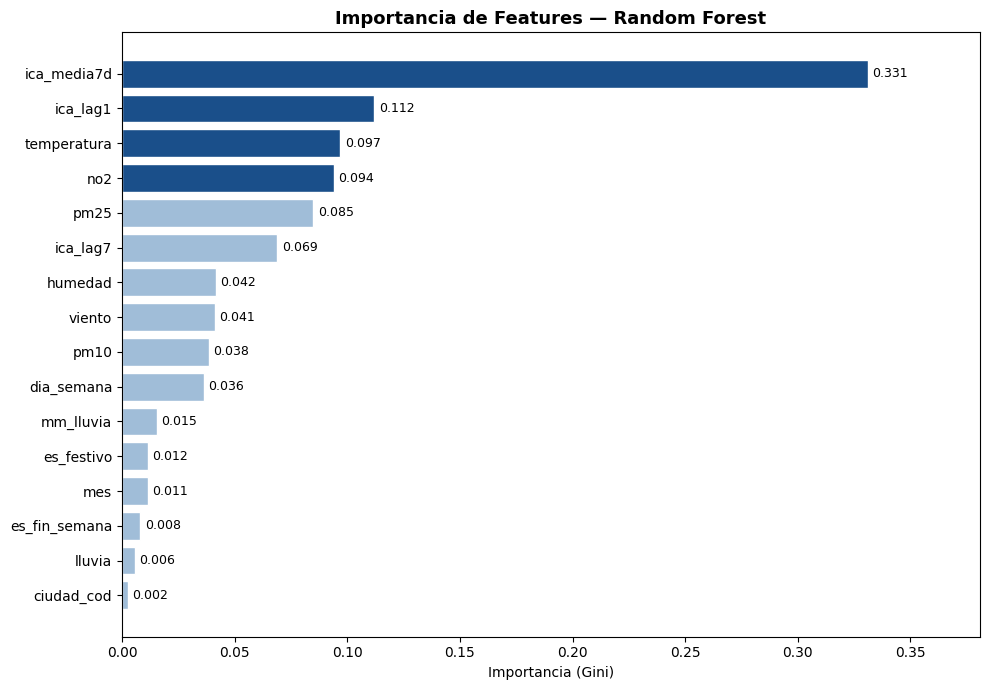

In [22]:
# 6.2 Importancia de features
imp = pd.Series(reg.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10,7))
colores = ["#1A4F8A" if v>=imp.quantile(0.75) else "#A0BDD8" for v in imp.values]
bars = ax.barh(imp.index, imp.values, color=colores, edgecolor="white")
ax.set_title("Importancia de Features — Random Forest", fontsize=13, fontweight="bold")
ax.set_xlabel("Importancia (Gini)")
for bar,val in zip(bars,imp.values):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2, f"{val:.3f}", va="center", fontsize=9)
ax.set_xlim(0, imp.max()*1.15)
plt.tight_layout()
plt.savefig(MODEL_PATH+"importancia_features.png", dpi=150, bbox_inches="tight")
plt.show()


# Análisis de featrues

Presenta la importancia de la features para el aporte al modelo, sin embargo, no se ha removido ninguna

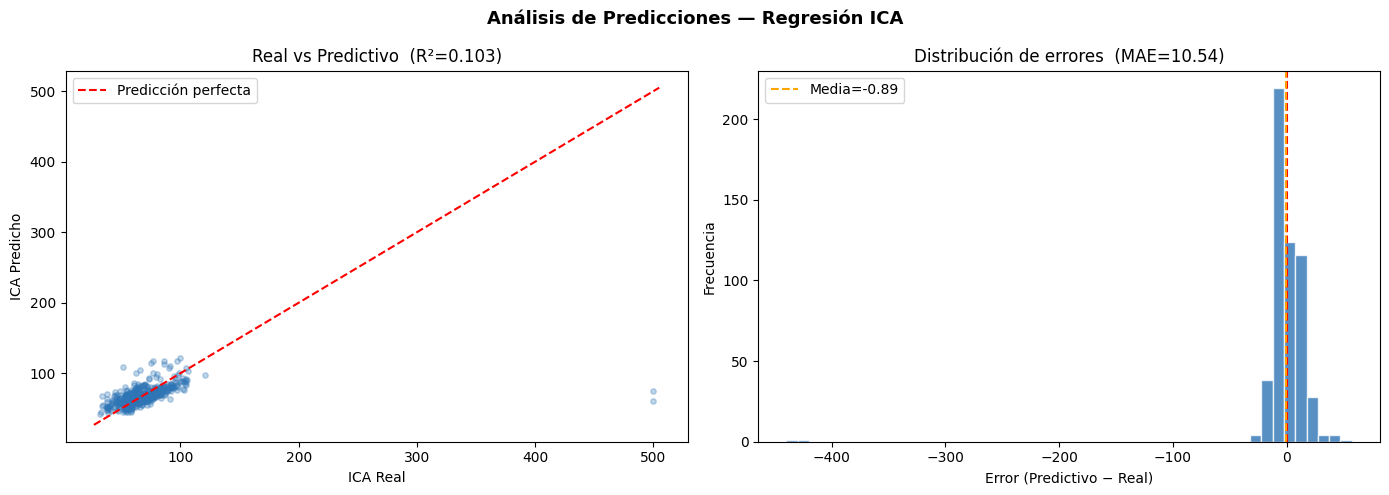

In [24]:
# 6.3 Real vs Predictivo y distribución de errores
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle("Análisis de Predicciones — Regresión ICA", fontsize=13, fontweight="bold")

axes[0].scatter(y_te_reg, y_pred_reg, alpha=0.3, color="#2E75B6", s=15)
lims = [min(y_te_reg.min(),y_pred_reg.min())-5, max(y_te_reg.max(),y_pred_reg.max())+5]
axes[0].plot(lims,lims,"r--",lw=1.5,label="Predicción perfecta")
axes[0].set_xlabel("ICA Real"); axes[0].set_ylabel("ICA Predicho")
axes[0].set_title(f"Real vs Predictivo  (R²={r2:.3f})"); axes[0].legend()

errores = y_pred_reg - y_te_reg.values
axes[1].hist(errores, bins=50, color="#2E75B6", alpha=0.8, edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", lw=1.5)
axes[1].axvline(errores.mean(), color="orange", linestyle="--", lw=1.5,
                label=f"Media={errores.mean():.2f}")
axes[1].set_xlabel("Error (Predictivo − Real)"); axes[1].set_ylabel("Frecuencia")
axes[1].set_title(f"Distribución de errores  (MAE={mae:.2f})"); axes[1].legend()

plt.tight_layout()
plt.savefig(MODEL_PATH+"predictivo_vs_real.png", dpi=150, bbox_inches="tight")
plt.show()


Análisis Real vs Predictivo

La línea diagonal roja punteada representa la 'predicción perfecta', donde los valores reales y predichos serían idénticos.

La mayoría de los puntos se agrupan alrededor de esta línea, lo que indica que el modelo tiende a predecir valores cercanos a los reales. Sin embargo, hay una dispersión notable, especialmente a medida que el valor del ICA aumenta, donde los puntos se alejan más de la línea perfecta

El pico del histograma de la derecha, está cerca de cero, lo que significa que la mayoría de las predicciones tienen errores pequeños. La línea punteada naranja (Media = -0.58) indica que el modelo tiene una ligera tendencia a subestimar el ICA real, aunque la media está muy cerca de cero, lo que es deseable.

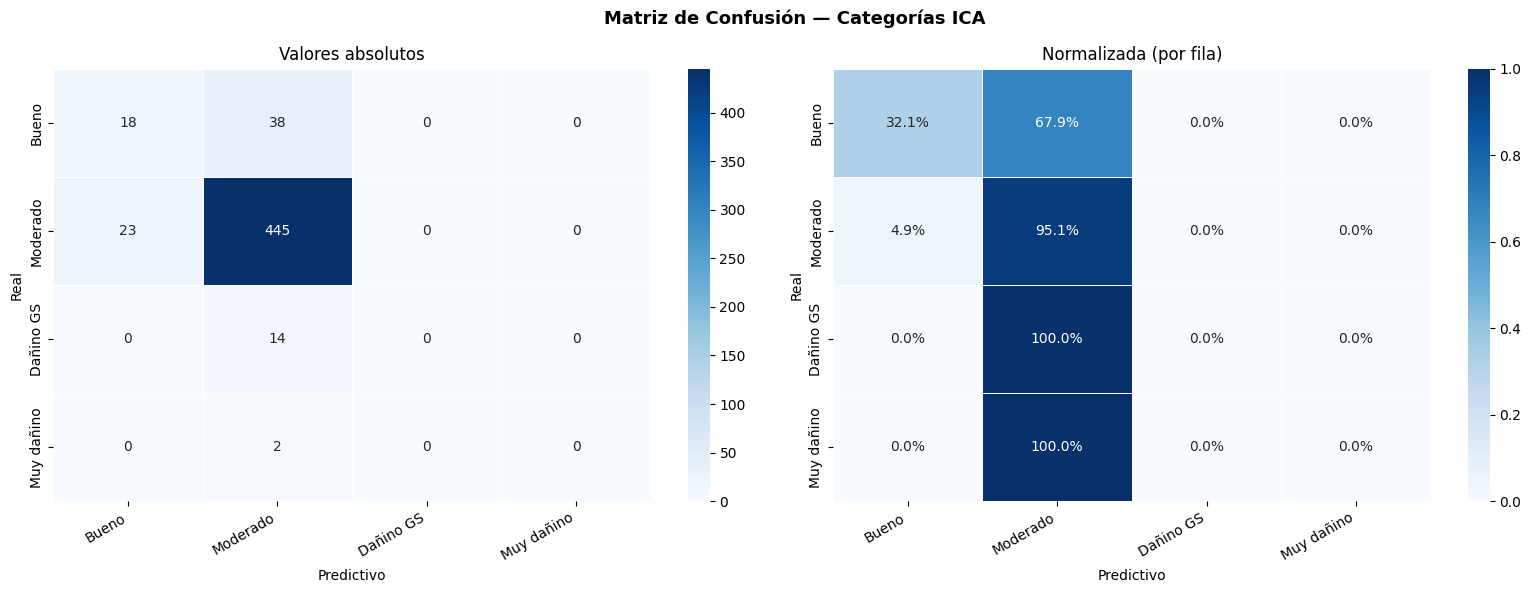


 Reporte de clasificación:
              precision    recall  f1-score   support

       Bueno       0.44      0.32      0.37        56
    Moderado       0.89      0.95      0.92       468
   Dañino GS       0.00      0.00      0.00        14
  Muy dañino       0.00      0.00      0.00         2

    accuracy                           0.86       540
   macro avg       0.33      0.32      0.32       540
weighted avg       0.82      0.86      0.84       540



In [30]:
# 6.4 Matriz de confusión
cats_test   = sorted(y_te_cat.unique())
labels_test = [CAT_LABELS[i] for i in cats_test]
cm          = confusion_matrix(y_te_cat, y_pred_cat, labels=cats_test)
cm_norm     = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
fig.suptitle("Matriz de Confusión — Categorías ICA", fontsize=13, fontweight="bold")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=labels_test, yticklabels=labels_test, linewidths=0.5)
axes[0].set_title("Valores absolutos")
axes[0].set_ylabel("Real"); axes[0].set_xlabel("Predictivo")
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Blues", ax=axes[1],
            xticklabels=labels_test, yticklabels=labels_test, linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title("Normalizada (por fila)")
axes[1].set_ylabel("Real"); axes[1].set_xlabel("Predictivo")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig(MODEL_PATH+"matriz_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n Reporte de clasificación:")
print(classification_report(y_te_cat, y_pred_cat,
      labels=cats_test, target_names=labels_test, zero_division=0))


# Analisis de la Matriz de Confusión



*   Categoría 'Bueno' (ICA bajo): Cuando el ICA real era 'Bueno', el modelo solo acertó el 32.1% de las veces. La mayoría de las veces (67.9%) lo confundió con 'Moderado'. Esto significa que le cuesta un poco identificar cuándo el aire es realmente 'Bueno'.

*   Categoría 'Moderado' (ICA medio): ¡Aquí el modelo lo hizo muy bien! Cuando el ICA real era 'Moderado', el modelo lo predijo correctamente un 95.1% de las veces. Es su punto fuerte.

*   Categoría 'Dañino para grupos sensibles' (ICA alto): Lamentablemente, cuando el ICA real era 'Dañino para grupos sensibles', el modelo se equivocó en el 100% de los casos, prediciendo siempre 'Moderado'. Es probable que esto se deba a que hay muy pocos ejemplos de esta categoría para que el modelo aprenda bien.

*   Categoría 'Muy dañino' (ICA muy alto): Similar al caso anterior, cuando el ICA real era 'Muy dañino', el modelo falló en el 100% de los casos, clasificándolo como 'Moderado'. También hay muy pocos datos de esta categoría.

En resumen, el modelo es muy bueno detectando cuando el ICA es 'Moderado'. Sin embargo, tiene dificultades para predecir correctamente las categorías de 'Bueno' y especialmente las categorías más críticas como 'Dañino para grupos sensibles' y 'Muy dañino'. Esto último es un problema común en los modelos cuando tienen muy pocos ejemplos para aprender de ciertas categorías.


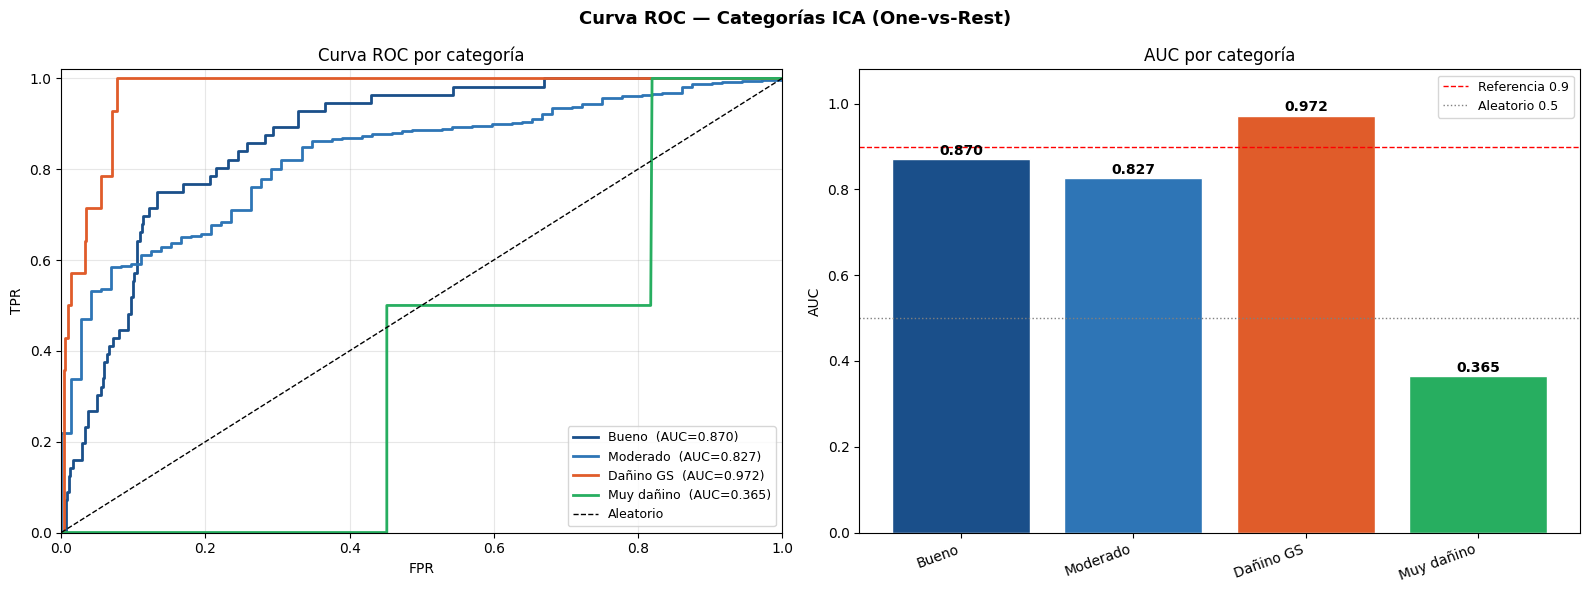


 AUC por categoría:
  Bueno                          AUC=0.8699  
  Moderado                       AUC=0.8267  
  Dañino GS                      AUC=0.9723  
  Muy dañino                     AUC=0.3648  

  AUC promedio macro: 0.7584


In [27]:
# 6.5 Curva ROC y AUC (one-vs-rest)
COLORES    = ["#1A4F8A","#2E75B6","#E05C2A","#27AE60","#8E44AD"]
cats_test  = sorted(y_te_cat.unique())
labels_pr  = [CAT_LABELS[i] for i in cats_test]
y_test_bin = label_binarize(y_te_cat, classes=cats_test)
idx_map    = [list(clf.classes_).index(c) for c in cats_test if c in clf.classes_]
y_score    = y_pred_proba[:, idx_map]

fig, axes = plt.subplots(1, 2, figsize=(16,6))
fig.suptitle("Curva ROC — Categorías ICA (One-vs-Rest)", fontsize=13, fontweight="bold")

aucs = []
for i,(cat_i,label) in enumerate(zip(cats_test,labels_pr)):
    if y_test_bin[:,i].sum()==0: continue
    fpr,tpr,_ = roc_curve(y_test_bin[:,i], y_score[:,i])
    roc_auc   = auc(fpr,tpr); aucs.append((label,roc_auc))
    axes[0].plot(fpr,tpr,color=COLORES[i%len(COLORES)],lw=2,
                 label=f"{label}  (AUC={roc_auc:.3f})")

axes[0].plot([0,1],[0,1],"k--",lw=1,label="Aleatorio")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("Curva ROC por categoría")
axes[0].legend(loc="lower right",fontsize=9)
axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.02]); axes[0].grid(alpha=0.3)

lbs  = [a[0] for a in aucs]; vals = [a[1] for a in aucs]
bars = axes[1].bar(lbs, vals, color=COLORES[:len(lbs)], edgecolor="white")
axes[1].axhline(0.9,color="red",  linestyle="--",lw=1,label="Referencia 0.9")
axes[1].axhline(0.5,color="gray", linestyle=":", lw=1,label="Aleatorio 0.5")
axes[1].set_ylim([0,1.08]); axes[1].set_title("AUC por categoría")
axes[1].set_ylabel("AUC"); axes[1].legend(fontsize=9)
for bar,val in zip(bars,vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.01,
                 f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.savefig(MODEL_PATH+"curva_roc.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n AUC por categoría:")
for label,roc_auc in aucs:
    estrellas = "" if roc_auc>=0.95 else "" if roc_auc>=0.85 else ""
    print(f"  {label:<30} AUC={roc_auc:.4f}  {estrellas}")
print(f"\n  AUC promedio macro: {np.mean(vals):.4f}")


# Analisis del AUC

En principio el model es excelente para identificar condiciones 'Dañinas para grupos sensibles' y bastante bueno para 'Bueno' y 'Moderado'. Sin embargo, necesita mejoras significativas para la categoría 'Muy dañino', debido a es critico que el modelo no tenga un buen comportamiento para predecir esta categoria.

In [28]:
# 6.6 Resumen final
print("="*55)
print("  RESUMEN FINAL DEL MODELO")
print("="*55)
print(f"  MAE  : {mae:.2f} pts  |  RMSE : {rmse:.2f} pts  |  R² : {r2:.4f}")
print(f"  AUC macro : {np.mean(vals):.4f}")
print(f"\n  Top 3 predictores:")
for feat,v in pd.Series(reg.feature_importances_,index=FEATURES).nlargest(3).items():
    print(f"    {feat:<20} {v:.4f}")
print(f"\n  Archivos guardados en Drive ({MODEL_PATH}):")
for f in sorted(os.listdir(MODEL_PATH)):
    print(f"    {f}")
print("="*55)


  RESUMEN FINAL DEL MODELO
  MAE  : 10.54 pts  |  RMSE : 28.62 pts  |  R² : 0.1025
  AUC macro : 0.7584

  Top 3 predictores:
    ica_media7d          0.3312
    ica_lag1             0.1120
    temperatura          0.0968

  Archivos guardados en Drive (/content/drive/MyDrive/SQL/data/modelo_output/):
    curva_roc.png
    importancia_features.png
    matriz_confusion.png
    modelo_clasificacion.pkl
    modelo_regresion.pkl
    predicho_vs_real.png
    reporte_metricas.json
